# BERT pre-training: masked language modeling and next sentence prediction

Give a model the sentence **"I went to the ___ to withdraw some cash."** and ask it to fill the gap. You can do it because you read the words on *both* sides of the gap. BERT is trained to do the same thing. This notebook shows how that training task is built, why it has to look the way it does, and what a pretrained BERT has learned from it.

The [BERT](BERT.ipynb) notebook describes the architecture and the two pre-training tasks at a high level. Here we run them.

**What you will learn**

1. **Why masking is necessary:** an encoder with no causal mask lets every token see itself, so "predict the token at each position" teaches nothing. A small experiment shows this.
2. **Masked language modeling (MLM) inputs and labels:** the 15% selection, the 80/10/10 replacement rule, and the `-100` labels that keep unselected positions out of the loss.
3. **What the MLM head predicts:** how the right-hand context changes predictions.
4. **Next sentence prediction (NSP):** scoring sentence pairs with the pretrained NSP head, and the shortcut that random negatives allow.
5. **The full pre-training loss:** MLM loss plus NSP loss, checked against `BertForPreTraining`.

**Prerequisites:** [Attention Is All You Need](Attention_Is_All_You_Need.ipynb) (self-attention and masks), [WordPiece](../tokenizers/wordpiece_tokenizer.ipynb), and [BERT](BERT.ipynb). Softmax and cross-entropy.

**Setup:** written for **Kaggle with a GPU and internet on**. It uses `torch`, `transformers`, and `matplotlib`, which Kaggle preinstalls. Section 1 trains three tiny models from scratch and needs no download. Sections 2–5 download [`google-bert/bert-base-uncased`](https://huggingface.co/google-bert/bert-base-uncased) once (about 440 MB, Apache-2.0); it is cached after that. Nothing is written to `/kaggle/working`. The notebook also runs on a CPU, more slowly. All example sentences were written for this notebook.

**Contents**

1. Why a bidirectional encoder needs masking
2. MLM in Hugging Face: inputs, labels, and loss
3. What the pretrained MLM head predicts
4. Next sentence prediction
5. The full pre-training loss
6. After BERT: changes to the objectives
7. Summary, review questions, and references

In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import (
    AutoTokenizer,
    BertForMaskedLM,
    BertForNextSentencePrediction,
    BertForPreTraining,
    DataCollatorForLanguageModeling,
)

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

# Seeds make CPU runs repeatable. GPU kernels are not always deterministic,
# so numbers can differ slightly between runs on a GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | transformers {transformers.__version__} | device: {device}")

torch 2.10.0+cu128 | transformers 5.0.0 | device: cuda


## 1. Why a bidirectional encoder needs masking

A Transformer layer lets each position attend to a set of positions. The attention mask decides which ones.

- **GPT-2 (decoder):** a *causal* mask. Position $i$ may attend to positions $0, \dots, i$. To predict token $i+1$ it never sees token $i+1$, so "predict the next token at every position" is a real task.
- **BERT (encoder):** no causal mask. Position $i$ may attend to *every* position, including itself. This is what "bidirectional" means.

The cell below draws both masks for a six-token input. A filled cell means "the row may attend to the column".

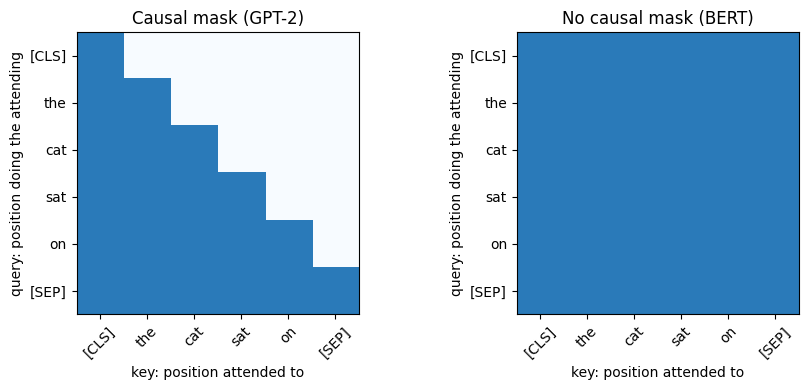

In [2]:
tokens = ["[CLS]", "the", "cat", "sat", "on", "[SEP]"]
T = len(tokens)
causal = torch.tril(torch.ones(T, T))    # row i sees columns 0..i
bidirectional = torch.ones(T, T)         # row i sees every column

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, m, title in [(axes[0], causal, "Causal mask (GPT-2)"),
                     (axes[1], bidirectional, "No causal mask (BERT)")]:
    ax.imshow(m, cmap="Blues", vmin=0, vmax=1.4)
    ax.set_xticks(range(T), tokens, rotation=45)
    ax.set_yticks(range(T), tokens)
    ax.set_xlabel("key: position attended to")
    ax.set_ylabel("query: position doing the attending")
    ax.set_title(title)
plt.tight_layout()
plt.show()

In both masks the diagonal is filled: a position always sees its own input token. For GPT-2 that is harmless, because the target at position $i$ is the *next* token, and the causal mask hides it. For BERT, which sees every position, we have to choose the targets carefully. The danger is a target that is already in the input. The model can then **copy** the answer instead of working it out from context, and copying teaches it nothing about language.

### 1.1 Three ways the target can leak into the input

The first two scenarios are objectives one might naively try on a bidirectional encoder. The third occurs inside real BERT.

**Scenario 1: reconstruct the input (the target at position $i$ is token $i$).** Feed in `the cat sat on the mat` and train the model to output `the cat sat on the mat`: at every position, predict the token that is already there. This is an autoencoder with no corruption.

The model does not even need attention to solve it. Every Transformer layer has a **residual connection**: the layer's output is its input plus a correction. The embedding of token $i$ is therefore carried straight up to the top of the network at position $i$, and the output head only has to learn to read it back. The loss falls to almost zero, but the model has learned nothing about how words relate to each other.

**Scenario 2: predict the next token without a causal mask (the target at position $i$ is token $i+1$).** This is the tempting mistake: keep GPT's objective, "predict the next word", but drop the causal mask so the model can use both sides. Token $i+1$ is part of the input, and with bidirectional attention position $i$ can attend to position $i+1$ and copy the answer from its neighbor.

Blocking that one connection does not help. Suppose position $i$ is forbidden to attend to position $i+1$:

```text
layer 1:  position i+2 attends to position i+1   -> its vector now contains token i+1
layer 2:  position i   attends to position i+2   -> token i+1 reaches position i indirectly
```

In a stack of layers, information can reach a position through other positions. Devlin et al. (2019, Section 3.1) make this point: standard language models can only be trained left-to-right or right-to-left, "since bidirectional conditioning would allow each word to indirectly 'see itself', and the model could trivially predict the target word in a multi-layered context." This is why GPT-2 needs a *strict* causal mask: no path from a future position exists through any number of layers.

**How masked language modeling avoids Scenarios 1 and 2.** MLM removes the target from the input before the model sees it:

```text
input : the cat sat on the [MASK] .
target:                     mat
```

`mat` is nowhere in the input: not at its own position, not at a neighbor, and not reachable through any number of layers. The only way to predict it is from the context on both sides, which is exactly the skill we want the model to learn. Devlin et al. (2019) borrowed the idea from the *cloze* reading test (Taylor, 1953).

**Scenario 3: where copying does happen in real BERT.** BERT's 80/10/10 rule leaves 10% of the selected positions **unchanged**. At those positions, the target is the visible token at the same position, as in Scenario 1. This does not break training, for two reasons:

1. **It is rare:** 10% of the 15% selected tokens is about 1.5% of all tokens.
2. **The model cannot tell which positions they are.** A visible token at a selected position might be the original (correct) or a random replacement (wrong), and both look like normal text. Copying is therefore not a reliable shortcut. The model has to check every visible token against its context.

Copying is harmful when it is a guaranteed shortcut (Scenarios 1 and 2). In small doses that the model cannot rely on (Scenario 3), it is useful: it keeps the model's predictions at visible tokens accurate, which matters later because real inputs contain no `[MASK]`.

### 1.2 An experiment with a tiny encoder

To test these claims, we train three tiny encoders on a toy "language" in which a missing token can be recovered from context. The **copy** model uses the Scenario 1 objective. The two MLM models differ only in whether they include the Scenario 3 replacements. Each sequence is ten numbers forming an arithmetic progression modulo 20:

$$x_i = (s + d\,i) \bmod 20, \qquad i = 0, \dots, 9,$$

with a random start $s \in \{0, \dots, 19\}$ and a random step $d \in \{1, 2, 3\}$. "Modulo 20" keeps every number in the vocabulary range 0–19: a value of 20 or more wraps around like a clock, so 22 becomes 2 and 25 becomes 5. For example, $s = 7,\ d = 3$ gives `7 10 13 16 19 2 5 8 11 14`. If one number is hidden, its neighbors tell you what it was, just as "the cat sat on the ___" tells you the missing word.

The vocabulary has 20 number tokens plus one `[MASK]` token (ID 20). The three models are identical: a 2-layer Transformer encoder with no causal mask. Only the training objective differs.

| Objective | Input | Target positions in the loss |
|---|---|---|
| **Copy** | the clean sequence | every position: predict the token that is already there |
| **MLM, `[MASK]` only** | selected positions replaced by `[MASK]` | selected positions only |
| **MLM, 80/10/10** | of the selected positions, 80% become `[MASK]`, 10% a random token, 10% stay unchanged | selected positions only |

As in BERT, about 15% of positions are selected in each sequence. Because the sequences are short, we always select at least one position.

In [3]:
TOY_V, TOY_MASK, TOY_T = 20, 20, 10   # 20 number tokens, [MASK] has ID 20, length 10


def toy_batch(n):
    # n arithmetic progressions modulo 20, shape (n, TOY_T).
    start = torch.randint(0, TOY_V, (n, 1))
    step = torch.randint(1, 4, (n, 1))
    return ((start + step * torch.arange(TOY_T)) % TOY_V).to(device)


def toy_mask(x, rule, p=0.15):
    # Corrupt a batch for MLM training.
    #   x    : clean sequences, shape (B, T)
    #   rule : "mask_only" -> every selected position becomes [MASK]
    #          "80/10/10"  -> BERT's rule (80% [MASK], 10% random, 10% unchanged)
    # Returns (inp, labels), both of shape (B, T):
    #   inp    : the corrupted sequences the model sees
    #   labels : the original token at selected positions, -100 everywhere else

    # Step 1: choose which positions the model must predict.
    # torch.rand gives one uniform number in [0, 1) per position, so "< p" is True
    # with probability p: about 15% of positions are selected.
    selected = torch.rand(x.shape, device=x.device) < p   # bool, (B, T)

    # With T = 10, a sequence often gets no selected position at all (0.85**10 = 20%).
    # Force one random position per row so every sequence contributes to the loss.
    rows = torch.arange(len(x), device=x.device)                       # 0, 1, ..., B-1
    cols = torch.randint(0, TOY_T, (len(x),), device=x.device)         # one column per row
    selected[rows, cols] = True

    # Step 2: build the corrupted input. Start from a copy so x stays clean.
    inp = x.clone()
    if rule == "mask_only":
        inp[selected] = TOY_MASK                        # boolean indexing: all selected positions
    else:  # "80/10/10"
        # A second uniform number per position decides what happens to a selected position:
        #   r < 0.8        -> [MASK]        (80% of selected positions)
        #   0.8 <= r < 0.9 -> random token  (10%)
        #   r >= 0.9       -> unchanged     (10%), so nothing to do
        r = torch.rand(x.shape, device=x.device)
        inp[selected & (r < 0.8)] = TOY_MASK
        to_random = selected & (r >= 0.8) & (r < 0.9)
        n_random = int(to_random.sum())                 # how many positions need a random token
        inp[to_random] = torch.randint(0, TOY_V, (n_random,), device=x.device)  # number tokens only, never [MASK]

    # Step 3: labels. Keep the original token where selected and put -100 elsewhere,
    # so cross_entropy(..., ignore_index=-100) scores only the selected positions.
    # The labels come from x, not inp, so even a random or unchanged position
    # is scored against its original token.
    labels = x.masked_fill(~selected, -100)
    return inp, labels


class TinyEncoder(nn.Module):
    def __init__(self, d=64, heads=4, layers=2):
        # d      : hidden size, the length of the vector that represents each token at every
        #          layer (BERT-Base uses 768). Embeddings, attention, and the output head all use it.
        # heads  : attention heads per layer; each head works on d / heads = 16 dimensions
        # layers : number of stacked encoder layers
        super().__init__()
        self.tok = nn.Embedding(TOY_V + 1, d)    # +1 for [MASK]
        self.pos = nn.Embedding(TOY_T, d)
        layer = nn.TransformerEncoderLayer(
            d_model=d,                 # size of each token vector
            nhead=heads,               # number of attention heads (d_model must divide evenly)
            dim_feedforward=4 * d,     # hidden size of the feed-forward sublayer, 4x as in BERT
            dropout=0.0,               # no dropout: the toy task is small and has no noise
            batch_first=True,          # tensors are (batch, seq, feature), not (seq, batch, feature)
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer=layer,       # the layer defined above, used as a template
            num_layers=layers,         # stack this many independent copies of it
        )                              # no attention mask is passed in forward(): bidirectional
        self.head = nn.Linear(d, TOY_V)                        # scores for the 20 number tokens

    def forward(self, x):                                      # x: (B, T) -> logits (B, T, 20)
        positions = torch.arange(x.shape[1], device=x.device)
        return self.head(self.encoder(self.tok(x) + self.pos(positions)))


x = toy_batch(2)
inp, labels = toy_mask(x, "80/10/10")
print("clean :", x[0].tolist())
print("input :", inp[0].tolist(), "  (20 = [MASK])")
print("labels:", labels[0].tolist(), "  (-100 = not in the loss)")

clean : [4, 7, 10, 13, 16, 19, 2, 5, 8, 11]
input : [4, 7, 5, 13, 20, 19, 2, 5, 8, 11]   (20 = [MASK])
labels: [-100, -100, 10, -100, 16, -100, -100, -100, -100, -100]   (-100 = not in the loss)


The training loop is the same for all three objectives. `F.cross_entropy(..., ignore_index=-100)` averages the loss over positions whose label is not `-100`. For the copy objective, every label is a real token.

In [4]:
def train_toy(objective, steps=400, batch_size=256, lr=1e-3):
    torch.manual_seed(1)                     # same initial weights for every objective
    model = TinyEncoder().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    for _ in range(steps):
        x = toy_batch(batch_size)
        inp, labels = (x, x) if objective == "copy" else toy_mask(x, objective)
        logits = model(inp)
        loss = F.cross_entropy(logits.reshape(-1, TOY_V), labels.reshape(-1), ignore_index=-100)
        opt.zero_grad()
        loss.backward()
        opt.step()
    return model, loss.item()


@torch.no_grad()
def evaluate_toy(model, n=2000):
    torch.manual_seed(123)                   # the same test sequences for every model
    x = toy_batch(n)
    clean_acc = (model(x).argmax(-1) == x).float().mean().item()
    inp, labels = toy_mask(x, "mask_only")   # test: hide tokens with [MASK]
    hidden = labels != -100
    masked_acc = (model(inp).argmax(-1)[hidden] == x[hidden]).float().mean().item()
    return clean_acc, masked_acc


toy_results = {}
for objective in ["copy", "mask_only", "80/10/10"]:
    model, final_loss = train_toy(objective)
    toy_results[objective] = evaluate_toy(model)
    clean_acc, masked_acc = toy_results[objective]
    print(f"{objective:>9}: final train loss {final_loss:.3f} | "
          f"accuracy on clean input {clean_acc:6.1%} | at [MASK] positions {masked_acc:6.1%}")

     copy: final train loss 0.003 | accuracy on clean input 100.0% | at [MASK] positions   5.5%
mask_only: final train loss 0.014 | accuracy on clean input  75.8% | at [MASK] positions  99.6%
 80/10/10: final train loss 0.046 | accuracy on clean input 100.0% | at [MASK] positions  99.7%


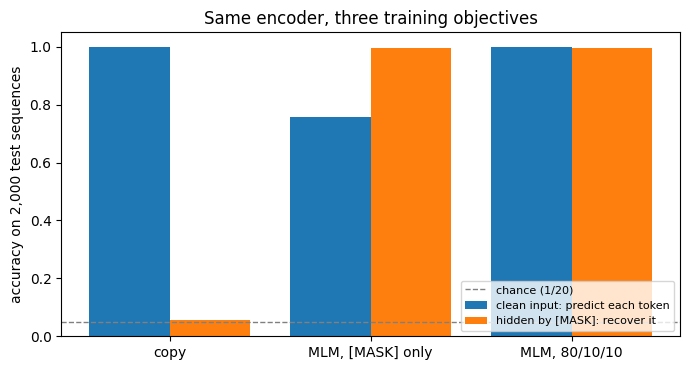

In [5]:
names = list(toy_results)
xs = list(range(len(names)))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar([x - 0.2 for x in xs], [toy_results[k][0] for k in names], 0.4, label="clean input: predict each token")
ax.bar([x + 0.2 for x in xs], [toy_results[k][1] for k in names], 0.4, label="hidden by [MASK]: recover it")
ax.axhline(1 / TOY_V, color="gray", ls="--", lw=1, label="chance (1/20)")
ax.set_xticks(xs, ["copy", "MLM, [MASK] only", "MLM, 80/10/10"])
ax.set_ylabel("accuracy on 2,000 test sequences")
ax.set_ylim(0, 1.05)
ax.set_title("Same encoder, three training objectives")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Reading the results.** In a CPU run of this setup, the three rows came out at about: copy 100% on clean input and 5% at `[MASK]` positions; MLM with `[MASK]` only 71% and 99.7%; MLM with 80/10/10 100% and 99.7%. Your numbers may differ slightly, especially on a GPU, but the pattern should hold:

- **Copy:** its training loss drops to almost zero, yet at hidden positions it is at chance. It learned to copy and never learned that neighboring numbers constrain each other. A low training loss does not mean the model learned anything useful.
- **MLM, `[MASK]` only:** it recovers hidden tokens almost perfectly, so it learned the structure of the sequences. But it is noticeably worse on clean input, because it was never trained to predict a position whose token is visible. After pre-training, a model sees normal text without `[MASK]`, so this gap matters.
- **MLM, 80/10/10:** it keeps the context skill and closes the gap. Random replacements mean the visible token might be wrong, so the model must check it against context. Unchanged positions mean it is also trained on real, visible tokens.

This is the reasoning behind BERT's 80/10/10 rule: it reduces the mismatch between pre-training inputs, which contain `[MASK]`, and the inputs used later, which do not.

## 2. MLM in Hugging Face: inputs, labels, and loss

Now the real model. We load the WordPiece tokenizer of `bert-base-uncased` and a few short example "documents". Section 4 reuses the documents for next sentence prediction.

In [6]:
MODEL_NAME = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Short example documents, written for this notebook. Each is four sentences in order.
docs = {
    "cricket": [
        "The match began at nine in the morning.",
        "The home team won the toss and chose to bat first.",
        "Their opening pair scored a hundred runs before lunch.",
        "After lunch the spinners took four quick wickets.",
    ],
    "cooking": [
        "Soak the rice and lentils overnight.",
        "In the morning, grind them into a smooth batter.",
        "Leave the batter in a warm place to ferment.",
        "Spread it thinly on a hot pan to make dosas.",
    ],
    "monsoon": [
        "The monsoon reached the coast in early June.",
        "Heavy rain flooded several low-lying streets.",
        "Schools in the city closed for two days.",
        "By the weekend the water had drained away.",
    ],
    "train": [
        "We reached the station an hour early.",
        "The train was late because of fog.",
        "When it finally arrived, we found our seats quickly.",
        "The journey to Delhi took eleven hours.",
    ],
    "laptop": [
        "My laptop became very slow last month.",
        "I checked the disk and found it was almost full.",
        "Deleting old videos freed up a lot of space.",
        "Now the laptop starts in a few seconds.",
    ],
    "astronomy": [
        "The telescope was set up on the roof.",
        "We waited for the clouds to clear.",
        "Around midnight, Saturn appeared above the trees.",
        "Its rings were clearly visible through the eyepiece.",
    ],
}
sentences = [s for doc in docs.values() for s in doc]
print(len(sentences), "sentences; vocabulary size", tokenizer.vocab_size)
print(tokenizer.tokenize(sentences[0]))
print("[MASK] id:", tokenizer.mask_token_id, "| special tokens:", tokenizer.all_special_tokens)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

24 sentences; vocabulary size 30522
['the', 'match', 'began', 'at', 'nine', 'in', 'the', 'morning', '.']
[MASK] id: 103 | special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


### 2.1 Building masked inputs with a data collator

`DataCollatorForLanguageModeling` turns tokenized sentences into an MLM batch. With `mlm=True` it pads the batch, selects about `mlm_probability` = 15% of the tokens, applies the 80/10/10 rule (its default), and builds `labels`:

- at a **selected** position, the label is the original token ID;
- everywhere else, the label is **`-100`**, PyTorch's default `ignore_index`, so the position adds nothing to the loss.

Special tokens (`[CLS]`, `[SEP]`, `[PAD]`) are never selected. We pass `return_special_tokens_mask=True` so the collator knows where they are.

The collator draws a new mask every time it builds a batch, so the same sentence is masked differently in each epoch. This is called **dynamic masking**. The original BERT pipeline masked the data once in preprocessing, and duplicated it so each sequence had several fixed masks.

#### What the collator receives

The collator does not take raw text. It takes `features`, a list with one tokenized entry per sentence (24 here). Each entry is a dictionary-like `BatchEncoding` whose four keys hold plain Python lists of integers, one number per token. For the first sentence, "The match began at nine in the morning.", the entry is:

| Token | `[CLS]` | the | match | began | at | nine | in | the | morning | . | `[SEP]` |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| `input_ids` | 101 | 1996 | 2674 | 2211 | 2012 | 3157 | 1999 | 1996 | 2851 | 1012 | 102 |
| `token_type_ids` | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| `attention_mask` | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |
| `special_tokens_mask` | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 |

- **`input_ids`**: each token's ID in the 30,522-entry WordPiece vocabulary. The tokenizer adds `[CLS]` (101) at the start and `[SEP]` (102) at the end. Both occurrences of "the" get the same ID, 1996.
- **`token_type_ids`**: the segment ID, 0 for sentence A and 1 for sentence B. A single sentence is all 0s.
- **`attention_mask`**: 1 for a real token, 0 for padding. All 1s here, because nothing has been padded yet.
- **`special_tokens_mask`**: 1 at `[CLS]` and `[SEP]`. This key appears only because we pass `return_special_tokens_mask=True`. The collator uses it to exclude these positions from selection.

Two things are still missing from `features`:

- **Padding.** Each entry is as long as its own sentence: 11 tokens here, but other sentences are shorter or longer. Lists of different lengths cannot be stacked into one tensor.
- **Masking and labels.** These are the clean, original token IDs.

Calling `collator(features[:4])` adds both. It pads the four entries to a common length `L` and converts them into tensors of shape `(4, L)`. It then selects about 15% of the eligible positions, applies the 80/10/10 rule to `input_ids`, builds `labels`, and drops `special_tokens_mask`, which has done its job. Because `features` itself is never modified, every call to the collator starts again from the clean IDs. That is what makes dynamic masking possible.

In [7]:
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
features = [tokenizer(s, return_special_tokens_mask=True) for s in sentences]

torch.manual_seed(SEED)
batch = collator(features[:4])
print({k: tuple(v.shape) for k, v in batch.items()})

# Unselected positions are unchanged, so the original sentence is:
# the label where one exists, otherwise the input token.
ids, labels = batch["input_ids"][0], batch["labels"][0]
original = torch.where(labels != -100, labels, ids)
print(f"\n{'pos':>3}  {'original':<12} {'input':<12} label")
for pos, (o, i, l) in enumerate(zip(original.tolist(), ids.tolist(), labels.tolist())):
    if batch["attention_mask"][0, pos] == 0:
        break
    label = tokenizer.convert_ids_to_tokens(l) if l != -100 else "-100"
    flag = "   <- selected" if l != -100 else ""
    print(f"{pos:>3}  {tokenizer.convert_ids_to_tokens(o):<12} {tokenizer.convert_ids_to_tokens(i):<12} {label}{flag}")

{'input_ids': (4, 14), 'token_type_ids': (4, 14), 'attention_mask': (4, 14), 'labels': (4, 14)}

pos  original     input        label
  0  [CLS]        [CLS]        -100
  1  the          the          -100
  2  match        [MASK]       match   <- selected
  3  began        [MASK]       began   <- selected
  4  at           at           -100
  5  nine         nine         -100
  6  in           in           -100
  7  the          the          -100
  8  morning      morning      -100
  9  .            .            -100
 10  [SEP]        [SEP]        -100


#### What the collator returns

`batch` is a `BatchEncoding` holding four PyTorch tensors, each of shape `(4, L)`: four sentences, padded to the length `L` of the longest one. `special_tokens_mask` is gone; the collator used it and dropped it.

| Key | Contents |
| --- | --- |
| `input_ids` | The **corrupted** token IDs that the model reads. Selected positions hold `[MASK]` (ID 103), a random token, or the original token; every other position is unchanged. Shorter sentences end in `[PAD]` (ID 0). |
| `token_type_ids` | Segment IDs, all 0 for single sentences, padded with 0. |
| `attention_mask` | 1 for real tokens and 0 for padding, so attention ignores the `[PAD]` positions. |
| `labels` | The **targets**: the original token ID at each selected position, and -100 everywhere else, including special tokens and padding. |

The printed table shows sentence 0 one position at a time. Read each row as follows:

- **`label` is -100:** the position was not selected. `input` equals `original`, and the position is not scored, but the model still uses it as context.
- **`label` is a token and `input` is `[MASK]`:** the 80% case.
- **`label` is a token and `input` is a different word:** the 10% random-replacement case.
- **`label` is a token and `input` equals `original`:** the 10% unchanged case. Nothing in `input_ids` reveals that this position was selected; only `labels` does. This is why the model must predict every token well, not only the masked ones (Section 1.1).

**An example batch.** When we ran this cell on a CPU with `transformers` 4.43.3 and `SEED = 0`, the collator produced `L = 14` and these tensors:

```text
input_ids
[[ 101  1996   103   103  2012  3157  1999  1996  2851  1012   102     0     0     0]
 [ 101  1996  2188  2136  2180  1996 10055  1998  4900  2000  7151  2034  1012   102]
 [ 101  2037  3098  3940  3195  1037  3634   103  2077  6265  1012   102     0     0]
 [ 101   103  6265  1996  6714 16912  2165  2176  4248 10370  1012   102     0     0]]

token_type_ids   all 0

attention_mask
[[1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 0 0]]

labels
[[-100 -100 2674 2211 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100]
 [-100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100]
 [-100 -100 -100 -100 -100 -100 -100 3216 -100 -100 -100 -100 -100 -100]
 [-100 2044 6265 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100]]
```

The same batch converted back to tokens (selected tokens in bold):

| Row | Original sentence | Input the model sees | Selected positions |
| --- | --- | --- | --- |
| 0 | the **match** **began** at nine in the morning . | the `[MASK]` `[MASK]` at nine in the morning . `[PAD]` `[PAD]` `[PAD]` | 2 and 3: both replaced by `[MASK]` |
| 1 | the home team won the toss and chose to bat first . | unchanged | none |
| 2 | their opening pair scored a hundred **runs** before lunch . | their opening pair scored a hundred `[MASK]` before lunch . `[PAD]` `[PAD]` | 7: replaced by `[MASK]` |
| 3 | **after** **lunch** the spin ##ners took four quick wickets . | `[MASK]` lunch the spin ##ners took four quick wickets . `[PAD]` `[PAD]` | 1: replaced by `[MASK]`; 2: "lunch", kept unchanged but still scored |

Things to notice:

- **Padding.** Row 1 is the longest sentence (14 tokens), so the others are padded with ID 0. `attention_mask` is 0 at those positions, and their labels are -100.
- **Labels hold the original IDs.** In row 0, 2674 is "match" and 2211 is "began".
- **The unchanged case.** In row 3, position 2 has input = label = 6265 ("lunch"). Only `labels` shows that it was selected.
- **A sentence with nothing selected.** Row 1 has no selected tokens, so it adds nothing to the MLM loss in this batch. It still costs computation.
- **Too few tokens to see the rates.** 6 of the 41 eligible tokens were selected (about 15%), but no random replacement appeared. Four sentences are far too few to check the 80/10/10 rule.

Your output may differ with another library version, because the selections depend on how it uses the random number generator. The structure is the same either way.

Over many batches the collator selects about 15% of the eligible tokens and splits them 80/10/10, and it never selects special tokens or padding. You will check these rates yourself in the [From text to BERT lab](../labs/text_to_bert/text_to_bert_lab.ipynb).

### 2.2 The MLM loss covers only the selected positions

Let $M$ be the set of selected positions across the whole batch and $\tilde{x}$ the corrupted input, after masking and replacement. The MLM loss is the average cross-entropy over the selected positions:

$$\mathcal{L}_{\text{MLM}} = -\frac{1}{|M|} \sum_{i \in M} \log p_\theta\left(x_i \mid \tilde{x}\right)$$

Here $x_i$ is the original token at position $i$, and $p_\theta(x_i \mid \tilde{x})$ is the probability the model gives it: the MLM head outputs logits over the 30,522-token vocabulary at every position, and a softmax turns the logits at position $i$ into a distribution. Because $M$ spans the whole batch, a sentence with three selected tokens counts three times as much as a sentence with one. Note the conditioning: the model sees the whole corrupted sequence $\tilde{x}$, left and right of $i$. A causal model conditions only on $x_{<i}$. Each selected token is predicted separately from the same $\tilde{x}$, so two masked tokens cannot inform each other.

The tensor shapes, for a batch of $B$ sequences of length $T$:

| Step | Tensor | Shape |
|---|---|---|
| Corrupted input | `input_ids` | `(B, T)` |
| Labels, `-100` except at selected positions | `labels` | `(B, T)` |
| Encoder output | `last_hidden_state` | `(B, T, 768)` |
| MLM head: transform, then project onto the vocabulary | `logits` | `(B, T, 30522)` |
| Loss over positions with label ≠ `-100` | `loss` | scalar |

The head computes logits at every position, but `ignore_index=-100` keeps all except the selected ones out of the loss. We load `BertForMaskedLM` and check that its built-in loss matches this formula.

When it loads, `transformers` may warn that some checkpoint weights were not used (the NSP head and the pooler). That is expected: this class has only the MLM head.

In [ ]:
# Download (first time only) and load BERT with its MLM head, move it to the GPU/CPU,
# and switch to evaluation mode, which turns off dropout so the outputs are deterministic.
mlm_model = BertForMaskedLM.from_pretrained(MODEL_NAME).to(device).eval()
# Count every weight in the model (numel = number of elements in a tensor), in millions.
print(f"parameters: {sum(p.numel() for p in mlm_model.parameters()) / 1e6:.1f} M")

# Move every tensor of the 4-sentence batch from Section 2.1 to the same device as the model.
batch = {k: v.to(device) for k, v in batch.items()}
# Inference only: do not record operations for backpropagation (saves memory and time).
with torch.no_grad():
    # Unpack the dict as keyword arguments: input_ids, token_type_ids, attention_mask, labels.
    # Because labels are passed, the model computes the MLM loss itself and returns it in out.loss.
    # out is MaskedLMOutput object with attributes loss, logits, hidden_states, attentions.
    # Here is contains loss (a scalar tensor) and logits (a tensor of shape (B, T, V), where V is the vocabulary size). 
    out = mlm_model(**batch)

# Vocabulary size, the last dimension of logits (B, T, V): 30,522 for bert-base-uncased.
V = out.logits.shape[-1]
# Recompute the loss by hand. Flatten logits to (B*T, V) and labels to (B*T,), so every
# position is one classification example; positions labelled -100 are skipped, and the
# result is the mean over the remaining (selected) positions, the formula above.
manual = F.cross_entropy(out.logits.reshape(-1, V), batch["labels"].reshape(-1), ignore_index=-100)
# Number of positions that contribute to the loss: the selected tokens, |M| in the formula.
n_in_loss = int((batch["labels"] != -100).sum())
# Number of real (non-padding) tokens in the batch, including [CLS] and [SEP].
n_real = int(batch["attention_mask"].sum())
# The head scores every vocabulary entry at every position: expect (4, T, 30522).
print("logits shape:", tuple(out.logits.shape))
# How small a fraction of the tokens actually produces a training signal.
print(f"positions in the loss: {n_in_loss} of {n_real} real tokens")
# The two numbers should agree, confirming that the built-in loss is the formula above.
print(f"model loss {out.loss.item():.4f} | manual loss {manual.item():.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


parameters: 109.5 M
logits shape: (4, 14, 30522)
positions in the loss: 5 of 49 real tokens
model loss 2.8919 | manual loss 2.8919
output projection tied to input embeddings: True


Two consequences follow:

- **Only about 15% of positions give a training signal.** GPT-2's causal objective gets a loss term at every position. BERT trades this efficiency for bidirectional context. ELECTRA (Section 6) is one attempt to get the signal back.
- **The `-100` convention is general.** The same trick removes padding and prompt tokens from the loss when fine-tuning causal models such as GPT-2 in Module 3.

**Weight tying:** the matrix that maps the final hidden vector to vocabulary scores is the same object as the input embedding matrix. Reading a token and predicting a token therefore use one shared embedding space.

## 3. What the pretrained MLM head predicts

The helper below runs the MLM model on a sentence containing `[MASK]` and returns the top-$k$ tokens and their probabilities at each mask.

In [9]:
# Run the whole function without recording operations for backpropagation (inference only).
@torch.no_grad()
def fill_mask(text, k=5):
    # Tokenize the sentence (adds [CLS] and [SEP]); return PyTorch tensors with a batch
    # dimension of 1, i.e. shape (1, T), and move them to the model's device.
    enc = tokenizer(text, return_tensors="pt").to(device)
    # Run BERT with its MLM head. No labels are passed, so no loss is computed.
    # logits has shape (1, T, vocab); [0] drops the batch dimension, giving (T, vocab).
    logits = mlm_model(**enc).logits[0]
    # Find the positions whose token ID is [MASK] (103). nonzero(as_tuple=True)[0] returns
    # their indices as a 1-D tensor, e.g. tensor([6]) for one mask; a sentence may have several.
    mask_pos = (enc["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
    # Keep only the rows of logits at the mask positions, then turn each row into a probability
    # distribution over the vocabulary with softmax. Shape: (number of masks, vocab).
    probs = logits[mask_pos].softmax(dim=-1)
    # For each mask, the k largest probabilities (top.values) and their token IDs (top.indices),
    # sorted from most to least likely. Both have shape (number of masks, k).
    top = probs.topk(k, dim=-1)
    # Build one list per mask of (token string, probability) pairs: the outer loop walks over
    # the masks, the inner loop over that mask's k candidates.
    return [[(tokenizer.convert_ids_to_tokens(int(i)), float(p)) for p, i in zip(pv, iv)]
            for pv, iv in zip(top.values, top.indices)]


def show(text, k=5):
    # Print the input sentence once.
    print(text)
    # Loop over the masks in order of position; m numbers them 0, 1, ...
    for m, preds in enumerate(fill_mask(text, k)):
        # Print that mask's k candidates with their probabilities, rounded to 2 decimals.
        print(f"   mask {m}: " + ", ".join(f"{t} ({p:.2f})" for t, p in preds))


# Try the helper on a simple sentence with one [MASK].
show("The cat sat on the [MASK].")

The cat sat on the [MASK].
   mask 0: floor (0.31), bed (0.12), couch (0.11), sofa (0.06), ground (0.06)


### 3.1 The right-hand context changes the prediction

The three sentences below share the left context "i went to the". A left-to-right model predicting the next word after "the" would see exactly the same input in all three cases. BERT also sees what comes after the gap.

In [10]:
for text in ["I went to the [MASK].",
             "I went to the [MASK] to withdraw some cash.",
             "I went to the [MASK] to see a doctor about my fever."]:
    show(text)
    print()

I went to the [MASK].
   mask 0: bathroom (0.25), door (0.21), kitchen (0.13), window (0.05), closet (0.02)

I went to the [MASK] to withdraw some cash.
   mask 0: bank (0.94), store (0.01), atm (0.01), office (0.00), counter (0.00)

I went to the [MASK] to see a doctor about my fever.
   mask 0: hospital (0.81), bathroom (0.03), doctor (0.02), clinic (0.02), hotel (0.01)



Compare the three top-5 lists. If the predictions shift toward words that fit the ending (money for the second sentence, medical care for the third), the model is using the right-hand context. A causal model cannot do this, because the ending has not been generated yet.

The bar chart shows the full top-10 distribution for one sentence. The probabilities come from one softmax over the whole vocabulary, so the top 10 need not sum to 1.

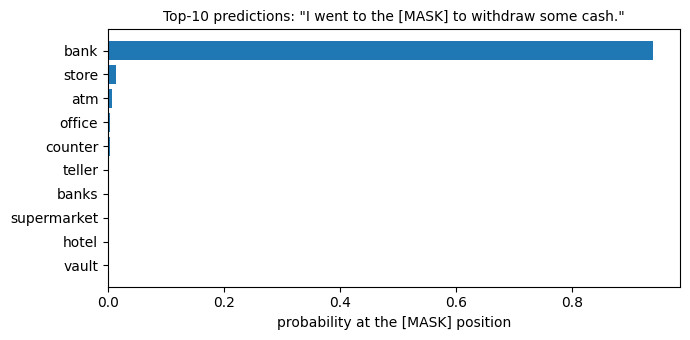

In [11]:
text = "I went to the [MASK] to withdraw some cash."
preds = fill_mask(text, k=10)[0]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh([t for t, _ in preds][::-1], [p for _, p in preds][::-1], color="tab:blue")
ax.set_xlabel("probability at the [MASK] position")
ax.set_title(f'Top-10 predictions: "{text}"', fontsize=10)
plt.tight_layout()
plt.show()

**Bias:** the MLM head reproduces associations in its training text (BooksCorpus and English Wikipedia). Templates such as "The nurse said that [MASK] would be late." can expose gendered associations. A probe of this kind is part of the [From text to BERT lab](../labs/text_to_bert/text_to_bert_lab.ipynb).

## 4. Next sentence prediction

NSP is a binary classification task on a sentence pair:

```text
[CLS] sentence A [SEP] sentence B [SEP]
```

The final hidden vector of `[CLS]` goes through a small classifier with two outputs. In Hugging Face, **label 0 means `IsNext`** (B follows A in the source document), and **label 1 means `NotNext`** (B is a random sentence from another document). During BERT pre-training, half the pairs were of each kind.

`BertForNextSentencePrediction` loads the pretrained NSP head from the same checkpoint. We score three kinds of pairs built from our documents:

| Pair type | How sentence B is chosen | Correct NSP label |
|---|---|---|
| **IsNext** | the next sentence in the same document | `IsNext` |
| **Random** | a sentence from a different document | `NotNext` |
| **Swapped** | the *previous* sentence of the same document (A and B swapped) | `NotNext`: B does not follow A |

Random and IsNext pairs are what NSP was trained on. Swapped pairs are a harder test: B is on the same topic but in the wrong order.

In [ ]:
# Load BERT with its pretrained NSP head (the same checkpoint as before; the cached download is
# reused), move it to the GPU/CPU, and switch to evaluation mode, which turns off dropout.
nsp_model = BertForNextSentencePrediction.from_pretrained(MODEL_NAME).to(device).eval()

# A separate, seeded random generator for choosing Random partners, so the pairs are reproducible.
rng = random.Random(SEED)
# One list of (sentence A, sentence B) pairs per pair type.
pairs = {"IsNext": [], "Random": [], "Swapped": []}
# Go through the six documents one at a time; doc is its list of four sentences, in order.
for topic, doc in docs.items():
    # All sentences from the *other* documents: the pool for Random pairs.
    # This can be interpreted like this
    # others = []
    # for t, d in docs.items():  
    #     if t != topic:         
    #         for s in d:        
    #             others.append(s)    
    others = [s for t, d in docs.items() if t != topic for s in d]
    # Consecutive sentences: (s1, s2), (s2, s3), (s3, s4), i.e. three pairs per document.
    for a, b in zip(doc[:-1], doc[1:]):
        # IsNext: B really is the sentence that follows A.
        pairs["IsNext"].append((a, b))
        # Random: keep A, replace B with a sentence from another document (a topic change).
        pairs["Random"].append((a, rng.choice(others)))
        # Swapped: same two sentences in the wrong order, so B is the sentence that came before A.
        pairs["Swapped"].append((b, a))



@torch.no_grad()
def p_is_next(pair_list):
    # Tokenize all pairs at once. Passing two lists makes each item "[CLS] A [SEP] B [SEP]" with
    # token_type_ids 0 for A and 1 for B; padding=True pads every pair to the longest one.
    enc = tokenizer([a for a, _ in pair_list], [b for _, b in pair_list],
                    padding=True, return_tensors="pt").to(device)
    # Run the model. The NSP head reads the [CLS] vector and gives two scores per pair:
    # logits has shape (number of pairs, 2); column 0 is IsNext, column 1 is NotNext.
    logits = nsp_model(**enc).logits
    # Softmax over the two columns turns the scores into probabilities; keep column 0,
    # P(IsNext), and move it to the CPU for printing and plotting.
    return logits.softmax(-1)[:, 0].cpu()


# Tokenize the first IsNext pair on its own (* unpacks the tuple into sentence A and sentence B).
enc = tokenizer(*pairs["IsNext"][0])
# Show the pair format: [CLS] A [SEP] B [SEP].
print("tokens        :", tokenizer.convert_ids_to_tokens(enc["input_ids"]))
# Show the segment IDs: 0 up to and including the first [SEP], then 1 for sentence B.
print("token_type_ids:", enc["token_type_ids"])
print()

# P(IsNext) for every pair, one tensor per pair type.
scores = {kind: p_is_next(pl) for kind, pl in pairs.items()}
# For each pair type: number of pairs, the average P(IsNext), and the fraction the head
# would classify as IsNext (probability above 0.5).
for kind, s in scores.items():
    print(f"{kind:>8}: {len(s)} pairs | mean P(IsNext) {s.mean():.3f} | "
          f"predicted IsNext (P > 0.5): {(s > 0.5).float().mean():.0%}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForNextSentencePrediction LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokens        : ['[CLS]', 'the', 'match', 'began', 'at', 'nine', 'in', 'the', 'morning', '.', '[SEP]', 'the', 'home', 'team', 'won', 'the', 'toss', 'and', 'chose', 'to', 'bat', 'first', '.', '[SEP]']
token_type_ids: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

  IsNext: 18 pairs | mean P(IsNext) 1.000 | predicted IsNext (P > 0.5): 100%
  Random: 18 pairs | mean P(IsNext) 0.278 | predicted IsNext (P > 0.5): 28%
 Swapped: 18 pairs | mean P(IsNext) 0.948 | predicted IsNext (P > 0.5): 94%


## 5. The full pre-training loss

BERT trains both tasks at once. For one corrupted pair $\tilde{x}$ with NSP label $y \in \{\text{IsNext}, \text{NotNext}\}$:

$$\mathcal{L} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{NSP}}, \qquad \mathcal{L}_{\text{NSP}} = -\log p_\theta\left(y \mid \tilde{x}\right)$$

$p_\theta(y \mid \tilde{x})$ is the softmax of the NSP head applied to the final `[CLS]` vector. Both losses are minimized, with equal weight.

`BertForPreTraining` has both heads. It returns `prediction_logits` with shape `(B, T, 30522)` for MLM and `seq_relationship_logits` with shape `(B, 2)` for NSP. Given both `labels` and `next_sentence_label`, it returns their sum as `loss`. We rebuild that sum by hand for one masked IsNext pair.

In [14]:
pt_model = BertForPreTraining.from_pretrained(MODEL_NAME).to(device).eval()

a, b = docs["cooking"][0], docs["cooking"][1]
torch.manual_seed(SEED)
while True:                                   # make sure at least one token is selected
    pair = collator([tokenizer(a, b, return_special_tokens_mask=True)])
    if (pair["labels"] != -100).any():
        break
pair = {k: v.to(device) for k, v in pair.items()}
nsp_label = torch.tensor([0], device=device)  # 0 = IsNext: b really follows a

print("input:", tokenizer.decode(pair["input_ids"][0]))
with torch.no_grad():
    out = pt_model(**pair, next_sentence_label=nsp_label)

V = out.prediction_logits.shape[-1]
mlm_loss = F.cross_entropy(out.prediction_logits.reshape(-1, V), pair["labels"].reshape(-1), ignore_index=-100)
nsp_loss = F.cross_entropy(out.seq_relationship_logits, nsp_label)
print("prediction_logits      :", tuple(out.prediction_logits.shape))
print("seq_relationship_logits:", tuple(out.seq_relationship_logits.shape))
print(f"MLM loss {mlm_loss.item():.4f} + NSP loss {nsp_loss.item():.4f} = {(mlm_loss + nsp_loss).item():.4f}")
print(f"BertForPreTraining loss: {out.loss.item():.4f}")

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

input: [CLS] so [MASK] frustrated rice and lentils overnight. [SEP] in [MASK] morning, grind them into a smooth batter. [SEP]
prediction_logits      : (1, 23, 30522)
seq_relationship_logits: (1, 2)
MLM loss 3.4688 + NSP loss 0.0001 = 3.4688
BertForPreTraining loss: 3.4688


This is the whole pre-training signal of the original BERT. Pre-training repeats this computation on very large numbers of such pairs and updates the weights with gradient descent. We only ran the forward pass on one pair: pre-training BERT-Base is far beyond a classroom notebook.

## 6. After BERT: changes to the objectives

BERT's two objectives were quickly revised. The table summarizes four well-known changes. Read the papers for the exact settings.

| Model | What changed | Motivation |
|---|---|---|
| **RoBERTa** (Liu et al., 2019) | Removed NSP; used dynamic masking, more data, and longer training | NSP did not help downstream results; BERT was undertrained |
| **ALBERT** (Lan et al., 2020) | Replaced NSP with sentence-order prediction (swapped pairs as negatives) | NSP can be solved by topic alone |
| **SpanBERT** (Joshi et al., 2020) | Masks contiguous spans instead of individual tokens | Predicting whole spans needs more context than predicting single subwords |
| **ELECTRA** (Clark et al., 2020) | A small generator replaces some tokens; the main model classifies *every* token as original or replaced | MLM learns from only about 15% of positions |

The same check applies to all of them: what is the target, which positions contribute to the loss, and can the model reach a low loss through a shortcut, as the copy model did?

## 7. Summary, review questions, and references

**Summary**

- BERT's encoder has no causal mask, so each position sees its own token. Predicting visible tokens can be solved by copying; MLM hides tokens so the model must use context.
- About 15% of non-special tokens are selected. Of those, 80% become `[MASK]`, 10% a random token, and 10% stay unchanged. Labels are `-100` everywhere else, so only the selected positions contribute to the loss.
- The pretrained MLM head uses both left and right context: changing only the words after a gap changes its prediction.
- NSP classifies sentence pairs from the `[CLS]` vector. Random negatives can be detected from topic alone, which led to NSP being dropped (RoBERTa) or replaced with sentence-order prediction (ALBERT).
- The original pre-training loss is the sum of the MLM and NSP cross-entropy losses.

**Review questions**

1. In Section 1, the copy model reached a training loss near zero. Why is that loss misleading, and what did the model learn?
2. Why was the `[MASK]`-only model worse on clean input than the 80/10/10 model? Why does this matter once BERT is fine-tuned on normal text?
3. A sequence has 128 real tokens, including `[CLS]` and two `[SEP]` tokens. About how many positions contribute to the MLM loss? How many would contribute to GPT-2's causal LM loss on 128 tokens?
4. Why does the collator never select `[CLS]`, `[SEP]`, or `[PAD]`?
5. Which shortcut do random NSP negatives allow? How do sentence-order prediction negatives remove it?
6. What is the difference between static and dynamic masking, and which one does `DataCollatorForLanguageModeling` implement?

**References**

- J. Devlin, M.-W. Chang, K. Lee, and K. Toutanova. [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://aclanthology.org/N19-1423/). NAACL-HLT, 2019.
- W. L. Taylor. "Cloze procedure": A new tool for measuring readability. *Journalism Quarterly*, 30(4), 1953.
- Y. Liu et al. [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692). arXiv:1907.11692, 2019.
- Z. Lan et al. [ALBERT: A Lite BERT for Self-supervised Learning of Language Representations](https://arxiv.org/abs/1909.11942). ICLR, 2020.
- M. Joshi et al. [SpanBERT: Improving Pre-training by Representing and Predicting Spans](https://arxiv.org/abs/1907.10529). TACL, 2020.
- K. Clark, M.-T. Luong, Q. V. Le, and C. D. Manning. [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555). ICLR, 2020.
- Hugging Face. [BERT model documentation](https://huggingface.co/docs/transformers/model_doc/bert) · [Data collators](https://huggingface.co/docs/transformers/main_classes/data_collator) · [`google-bert/bert-base-uncased` model card](https://huggingface.co/google-bert/bert-base-uncased).

**Next:** [GPT-2](GPT-2.ipynb), a decoder-only model trained with the causal objective.